# Hotel Booking Cancellation Prediction

## Notebook 01 — Data Understanding and Exploratory Data Analysis

**Module:** IT3051 – Fundamentals of Data Mining  
**Group:** Group 27 – Entropy Zero

### Machine Learning Task

Binary Classification

### Target Variable

`is_canceled`

- `0` — Not Cancelled
- `1` — Cancelled

### Notebook Objective

This notebook investigates the structure, quality, distributions, relationships,
and potential data leakage issues in the Hotel Booking Demand dataset before
data preprocessing and model development.


-------------------------------------

Import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Connect repository

In [3]:
import os

REPO_NAME = "IT3051-Group27-Hotel-Cancellation-Prediction"
REPO_URL = f"https://github.com/sudulran/{REPO_NAME}.git"
REPO_PATH = f"/content/{REPO_NAME}"

if not os.path.exists(REPO_PATH):
    !git clone {REPO_URL}
else:
    print("Repository already cloned.")

%cd {REPO_PATH}

Cloning into 'IT3051-Group27-Hotel-Cancellation-Prediction'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 74 (delta 25), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 1.33 MiB | 3.28 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/IT3051-Group27-Hotel-Cancellation-Prediction


Load raw dataset

In [4]:
DATA_PATH = "data/raw/hotel_bookings.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
print("Dataset shape:", df.shape)

Dataset shape: (119390, 32)


In [6]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 1. Initial Dataset Inspection

This section examines the overall structure of the dataset, including its dimensions, column names, data types, and descriptive statistics.

Dataset dimensions and columns

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Number of rows: 119390
Number of columns: 32

Column names:
1. hotel
2. is_canceled
3. lead_time
4. arrival_date_year
5. arrival_date_month
6. arrival_date_week_number
7. arrival_date_day_of_month
8. stays_in_weekend_nights
9. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
dtype_summary = df.dtypes.value_counts()

print("Data type summary:")
display(dtype_summary)

Data type summary:


,count
int64,16
object,12
float64,4


In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Number of numerical columns:", len(numeric_columns))
print("Number of categorical/text columns:", len(categorical_columns))

print("\nNumerical columns:")
print(numeric_columns)

print("\nCategorical/text columns:")
print(categorical_columns)

Number of numerical columns: 20
Number of categorical/text columns: 12

Numerical columns:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical/text columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


Numerical descriptive statistics

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


Categorical descriptive statistics

In [12]:
df.describe(include="object").T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


Unique-value counts

In [13]:
unique_counts = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique(dropna=False) for col in df.columns]
})

unique_counts

,Column,Unique Values
0,hotel,2
1,is_canceled,2
2,lead_time,479
3,arrival_date_year,3
4,arrival_date_month,12
5,arrival_date_week_number,53
6,arrival_date_day_of_month,31
7,stays_in_weekend_nights,17
8,stays_in_week_nights,35
9,adults,14


## 2. Target Variable Analysis

The target variable for this project is `is_canceled`.

- `0` represents a booking that was not cancelled.
- `1` represents a booking that was cancelled.

The distribution of the target variable is examined to identify whether class imbalance exists.

Validate target values

In [14]:
print("Unique target values:")
print(df["is_canceled"].unique())

print("\nTarget value counts:")
print(df["is_canceled"].value_counts())

Unique target values:
[0 1]

Target value counts:
is_canceled
0    75166
1    44224
Name: count, dtype: int64


Target percentages

In [15]:
target_counts = df["is_canceled"].value_counts().sort_index()
target_percentages = (
    df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary.index = ["Not Cancelled (0)", "Cancelled (1)"]

target_summary

,Count,Percentage
Not Cancelled (0),75166,62.96
Cancelled (1),44224,37.04


Target distribution graph

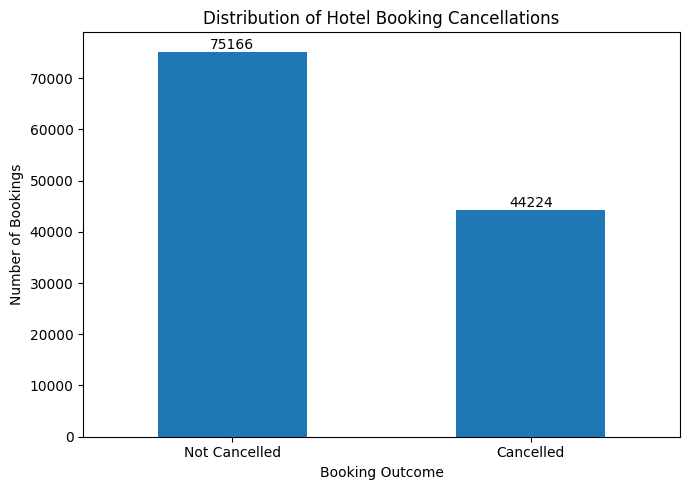

In [16]:
target_counts_named = df["is_canceled"].map({
    0: "Not Cancelled",
    1: "Cancelled"
}).value_counts()

ax = target_counts_named.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Distribution of Hotel Booking Cancellations")
plt.xlabel("Booking Outcome")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

total = len(df)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Target Distribution Observation

The dataset contains 75,166 non-cancelled bookings (approximately 62.96%) and 44,224 cancelled bookings (approximately 37.04%).

Therefore, the target variable is moderately imbalanced, with non-cancelled bookings forming the majority class. The imbalance is not extremely severe, but model evaluation should not rely only on accuracy. Metrics such as precision, recall, F1-score, ROC-AUC, and the confusion matrix will also be considered during model development.

## 3. Missing Value Analysis

Missing values are investigated to understand which variables contain incomplete information and how significant the missingness is.

No missing-value treatment is performed in this notebook. Appropriate handling strategies will be determined during the preprocessing stage.

Missing-value summary

In [17]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


Missing-value visualization

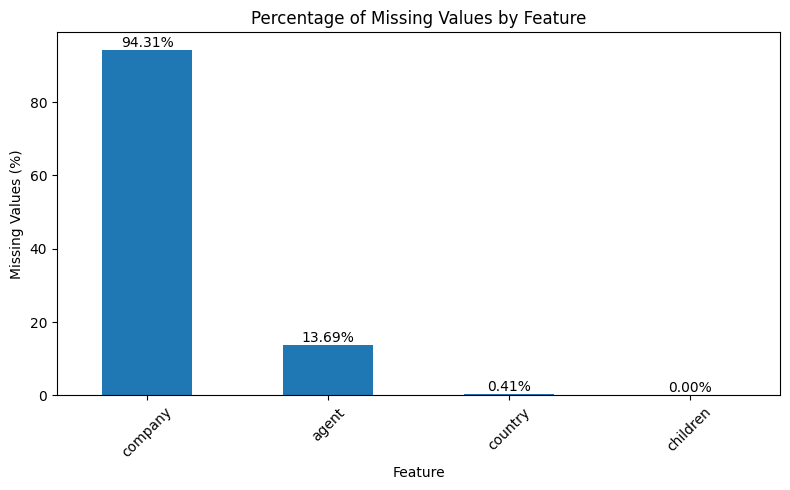

In [18]:
ax = missing_summary["Missing Percentage"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

### Missing Value Observations

Missing values occur in four attributes:

- `company` has the largest proportion of missing values, at approximately 94.31%.
- `agent` contains approximately 13.69% missing values.
- `country` contains only a small proportion of missing values, approximately 0.41%.
- `children` contains only four missing records.

The meaning of these missing values must be investigated before selecting a treatment strategy. For example, a missing `company` or `agent` value may potentially represent a booking that was not associated with a company or travel agent rather than an accidental loss of information.

Therefore, rows or columns will not be removed solely because they contain missing values at this stage.

## 4. Duplicate Record Investigation

Exact duplicate rows are investigated as a potential data-quality issue.

However, the dataset does not contain a unique booking identifier. Therefore, identical rows cannot automatically be assumed to represent erroneous duplicate bookings.

Count duplicates

In [19]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Number of exact duplicate rows:", duplicate_count)
print(f"Percentage of exact duplicate rows: {duplicate_percentage:.2f}%")

Number of exact duplicate rows: 31994
Percentage of exact duplicate rows: 26.80%


Inspect some duplicates

In [20]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
21,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
39,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.0,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
132,Resort Hotel,1,5,2015,July,28,5,1,0,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
198,Resort Hotel,0,0,2015,July,28,7,0,1,1,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08


### Duplicate Record Observation

The dataset contains 31,994 rows that are exact duplicates across all available attributes.

However, there is no unique reservation or booking identifier in the dataset. It is therefore possible that some identical rows represent separate bookings with the same recorded characteristics rather than accidental duplicate records.

The duplicate records will be investigated further during preprocessing before a final decision is made regarding removal.

## 5. Investigation of Unusual Observations

Several numerical variables are examined to identify observations that differ substantially from typical bookings.

These observations are not assumed to be errors. They may represent legitimate special cases such as group bookings, complimentary stays, day-use reservations, or other hotel-specific situations.

The purpose of this analysis is to identify records requiring further investigation before any preprocessing decision is made.

In [23]:
zero_guest_bookings = (
    (df["adults"] == 0) &
    (df["children"].fillna(0) == 0) &
    (df["babies"] == 0)
).sum()

zero_night_bookings = (
    (df["stays_in_weekend_nights"] == 0) &
    (df["stays_in_week_nights"] == 0)
).sum()

negative_adr = (df["adr"] < 0).sum()
zero_adr = (df["adr"] == 0).sum()
very_high_adr = (df["adr"] > 1000).sum()
large_adult_bookings = (df["adults"] > 10).sum()

unusual_summary = pd.DataFrame({
    "Observation": [
        "Bookings with zero recorded guests",
        "Bookings with zero recorded nights",
        "Bookings with negative ADR",
        "Bookings with ADR = 0",
        "Very high ADR values (>1000) for inspection",
        "Large-group bookings (>10 adults)"
    ],
    "Count": [
        zero_guest_bookings,
        zero_night_bookings,
        negative_adr,
        zero_adr,
        very_high_adr,
        large_adult_bookings
    ]
})

unusual_summary

,Observation,Count
0,Bookings with zero recorded guests,180
1,Bookings with zero recorded nights,715
2,Bookings with negative ADR,1
3,Bookings with ADR = 0,1959
4,Very high ADR values (>1000) for inspection,1
5,Large-group bookings (>10 adults),12


Inspect numerical extremes

In [24]:
selected_numeric_features = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "days_in_waiting_list",
    "adr"
]

df[selected_numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.00,0.000,0.0,26.0
days_in_waiting_list,119390.0,2.321149,17.594721,0.00,0.00,0.000,0.0,391.0
adr,119390.0,101.831122,50.535790,-6.38,69.29,94.575,126.0,5400.0


Inspect the negative ADR row

In [25]:
df[df["adr"] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0.0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273.0,NaN,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


Inspect extremely high ADR

In [26]:
df[df["adr"] > 1000]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
48515,City Hotel,1,35,2016,March,13,25,0,1,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,1,Non Refund,12.0,NaN,0,Transient,5400.0,0,0,Canceled,2016-02-19


Inspect zero-guest records

In [27]:
df[
    (df["adults"] == 0) &
    (df["children"].fillna(0) == 0) &
    (df["babies"] == 0)
].head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,NaN,174.0,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,NaN,174.0,0,Transient,0.0,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,0.0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05
4127,Resort Hotel,1,0,2016,February,8,15,0,0,0,0.0,0,SC,NaN,Offline TA/TO,TA/TO,0,0,0,P,P,0,No Deposit,NaN,383.0,0,Transient,0.0,0,0,Canceled,2016-02-15
9376,Resort Hotel,1,0,2016,November,48,21,0,0,0,0.0,0,SC,NaN,Offline TA/TO,TA/TO,0,0,0,P,P,0,No Deposit,NaN,386.0,0,Group,0.0,0,0,Canceled,2016-11-21
31765,Resort Hotel,0,31,2016,December,53,27,2,8,0,0.0,0,BB,PRT,Direct,Direct,0,0,0,D,D,3,No Deposit,NaN,NaN,0,Transient,28.0,1,0,Check-Out,2017-01-06
32029,Resort Hotel,0,4,2017,January,2,14,0,1,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,G,0,No Deposit,168.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2017-01-15
32827,Resort Hotel,0,46,2017,January,4,25,3,9,0,0.0,0,SC,FRA,Direct,Direct,0,0,0,A,I,8,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2017-02-06


### Unusual Value Observations

Several potentially unusual records were identified:

- 180 bookings contain no recorded adults, children, or babies.
- 715 bookings record zero weekend and zero weekday nights.
- One record contains a negative average daily rate (`adr`).
- 1,959 bookings have an `adr` equal to zero.
- One booking has an `adr` above 1,000.
- A small number of bookings contain unusually large numbers of adults.

These observations are not automatically classified as errors. Some may represent legitimate special booking situations, complimentary stays, group reservations, cancelled bookings, or other operational cases.

Appropriate treatment will therefore be determined during preprocessing after further investigation.

## 6. Numerical Feature Analysis

The distributions of important numerical features are examined to identify skewness, unusual observations, and possible relationships that may influence preprocessing and modelling decisions.

Histograms of selected numerical variables

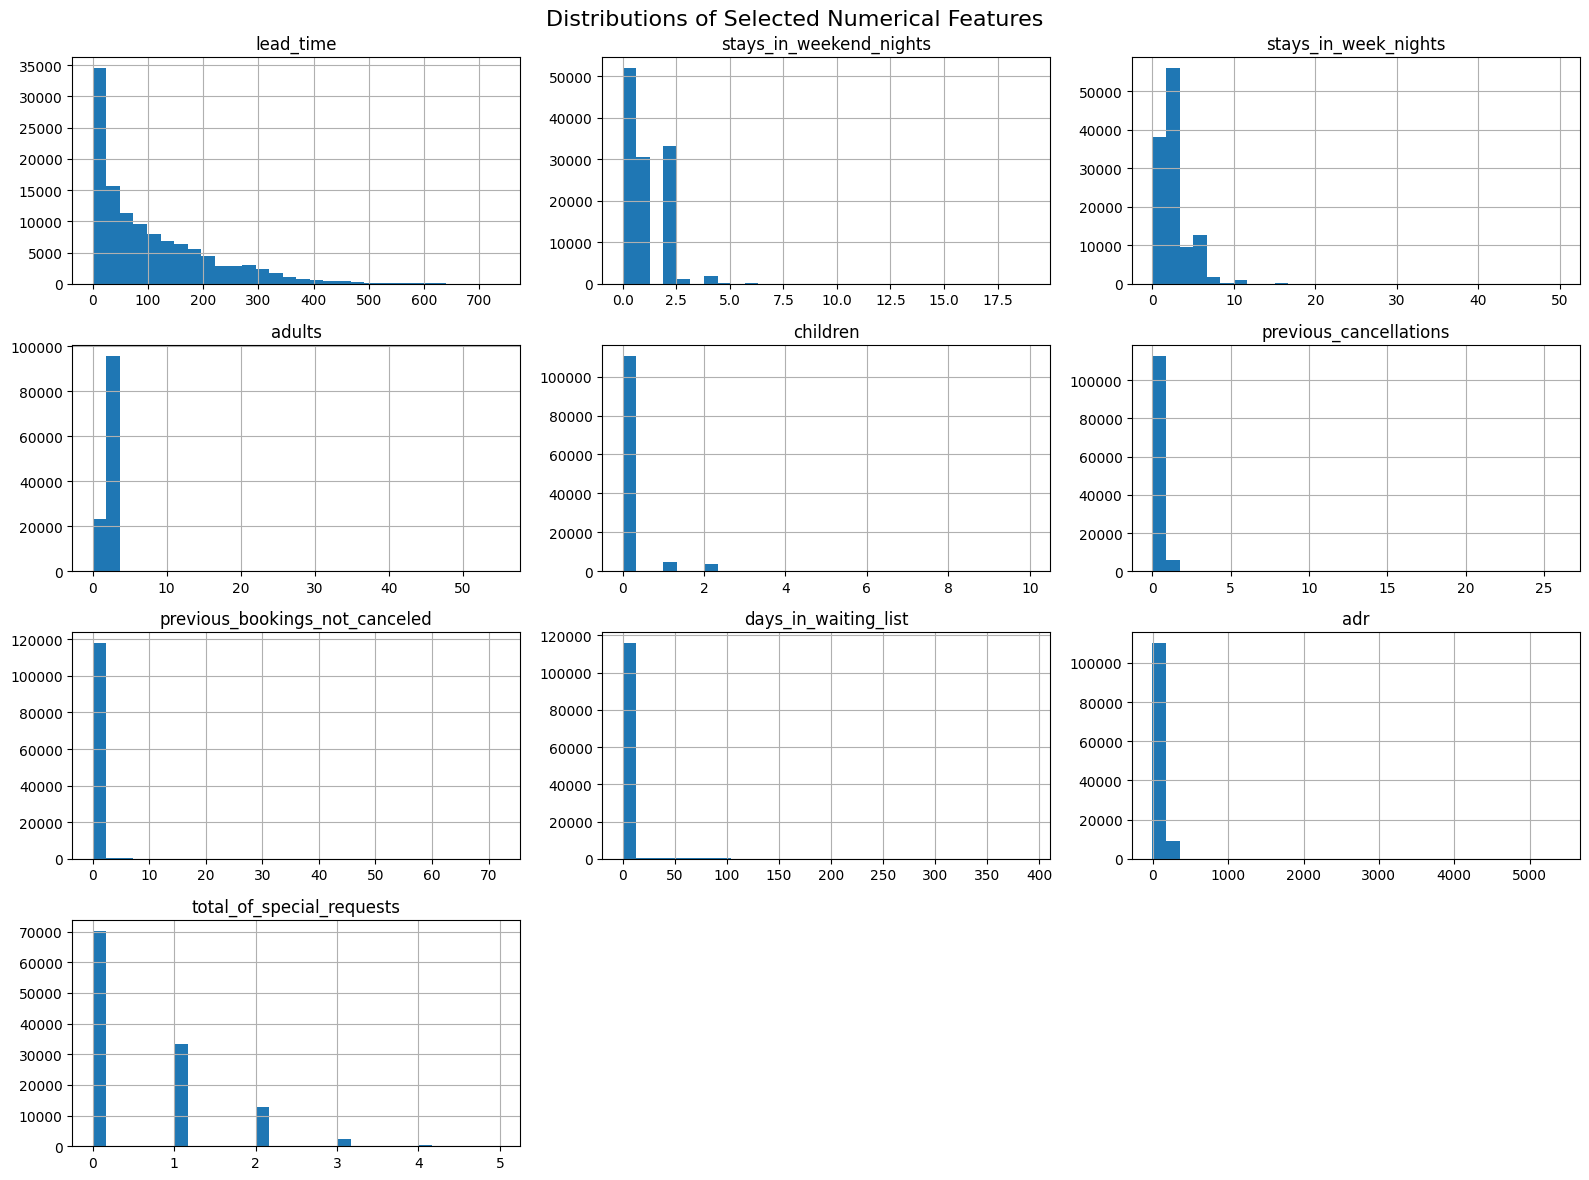

In [28]:
features_to_plot = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "days_in_waiting_list",
    "adr",
    "total_of_special_requests"
]

df[features_to_plot].hist(
    bins=30,
    figsize=(16, 12)
)

plt.suptitle(
    "Distributions of Selected Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

Boxplots for key continuous features

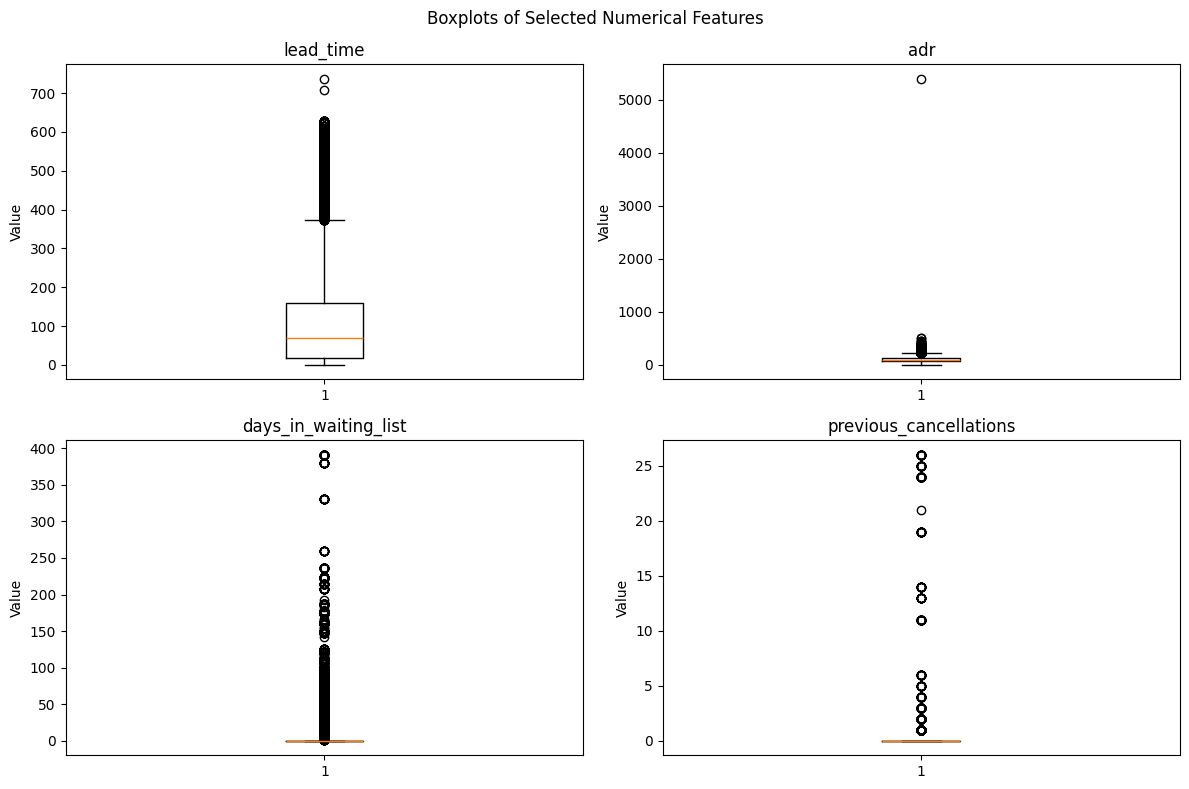

In [29]:
boxplot_features = [
    "lead_time",
    "adr",
    "days_in_waiting_list",
    "previous_cancellations"
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8)
)

for ax, feature in zip(axes.flatten(), boxplot_features):
    ax.boxplot(df[feature].dropna())
    ax.set_title(feature)
    ax.set_ylabel("Value")

plt.suptitle("Boxplots of Selected Numerical Features")
plt.tight_layout()
plt.show()

## 7. Categorical Feature Analysis

Categorical variables are examined to understand their possible values, frequency distributions, and whether some variables contain very high numbers of categories.

Unique categories per categorical column

In [30]:
categorical_summary = pd.DataFrame({
    "Feature": categorical_columns,
    "Unique Values": [
        df[col].nunique(dropna=False)
        for col in categorical_columns
    ]
})

categorical_summary.sort_values(
    by="Unique Values",
    ascending=False
)

,Feature,Unique Values
11,reservation_status_date,926
3,country,178
7,assigned_room_type,12
1,arrival_date_month,12
6,reserved_room_type,10
4,market_segment,8
5,distribution_channel,5
2,meal,5
9,customer_type,4
8,deposit_type,3
